<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/melchiors_catalog_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MELCHIORS Catalog → Alpy 600 FITS 1D

Cherche une etoile dans le catalogue MELCHIORS, telecharge le spectre HERMES, et exporte en FITS 1D pour Alpy 600.

In [1]:
pip install astropy openpyxl odfpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 22.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
from google.colab import files
import os

print('Selectionner le fichier catalogue_Melchiors_AB.ods...')
uploaded = files.upload()
CATALOG_FILE = list(uploaded.keys())[0]
print(f'Fichier catalogue charge : {CATALOG_FILE}')

Selectionner le fichier catalogue_Melchiors_AB.ods...


Saving catalogue_Melchiors_AB.ods to catalogue_Melchiors_AB.ods
Fichier catalogue charge : catalogue_Melchiors_AB.ods


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import urllib.request
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


In [4]:
# Charger le catalogue
catalog = pd.read_excel(CATALOG_FILE, sheet_name='catalogue_Melchiors', engine='odf')
print(f"Catalogue charge : {len(catalog)} entrees")
print(f"Colonnes : {list(catalog.columns)}")

Catalogue charge : 3256 entrees
Colonnes : ['Number', 'obsid', 'Spectrum png', 'Spectrum png link', 'TARGET catalog', 'TARGET number', 'Star name', 'Star name catalog', 'Star name number', 'V', 'B-V', 'Spectral type', 'RA', 'DEC', 'airmass', 'bsn', 'vsn', 'rsn', 'Spectrum fits', 'Unnamed: 19', 'Spectrum fits link']


In [5]:
# ---------------------------------------------------------------
# MODIFIER ICI : rentrer le nom de l'etoile
STAR_NAME = 'HD 153808'  # ou HD 18256, Vega, Altair, etc.
# ---------------------------------------------------------------

# Chercher dans le catalogue (case-insensitive)
matches = catalog[catalog['Star name'].str.contains(STAR_NAME, case=False, na=False)]

if len(matches) == 0:
    print(f'Etoile {STAR_NAME} non trouvee.')
    print(f'Exemples disponibles :')
    print(catalog['Star name'].dropna().head(20).tolist())
else:
    print(f"Trouve {len(matches)} spectre(s) pour {STAR_NAME}:")
    for idx, row in matches.iterrows():
        print(f"  {row['Star name']} - obsid={row['obsid']} - type={row['Spectral type']}")

Trouve 2 spectre(s) pour HD 153808:
  HD 153808 - obsid=340663 - type=A0V
  HD 153808 - obsid=340679 - type=A0V


In [6]:
# Prendre le premier match (ou modifier si plusieurs spectres pour une etoile)
selected = matches.iloc[0]
fits_url = selected['Spectrum fits link']
obsid = selected['obsid']
star_name = selected['Star name']
sptype = selected['Spectral type']

print(f"Selection : {star_name} ({sptype})")
print(f"  obsid : {obsid}")
print(f"  URL : {fits_url[:80]}...")

# Telecharger le FITS
print(f"\nTelechargement en cours...")
FITS_FILE = f'{obsid}_spectrum.fits'
try:
    urllib.request.urlretrieve(fits_url, FITS_FILE)
    print(f"Fichier telecharge : {FITS_FILE}")
    print(f"Taille : {os.path.getsize(FITS_FILE)/1024/1024:.1f} MB")
except Exception as e:
    print(f"Erreur telechargement : {e}")

Selection : HD 153808 (A0V)
  obsid : 340663
  URL : https://set-p-stweb.bm.icts.kuleuven.be/spectra/340663_melchiors_spectrum.fits...

Telechargement en cours...
Fichier telecharge : 340663_spectrum.fits
Taille : 6.4 MB


In [7]:
# Ouvrir le FITS telecharge
with fits.open(FITS_FILE) as hdul:
    header0 = hdul[0].header
    table = Table(hdul[1].data)

meta = {
    'object'    : header0.get('OBJECT', 'N/A'),
    'unseq'     : header0.get('UNSEQ', 'N/A'),
    'date_obs'  : header0.get('DATE-OBS', 'N/A'),
    'exptime'   : header0.get('EXPTIME', float('nan')),
    'instrume'  : header0.get('INSTRUME', 'N/A'),
    'telescop'  : header0.get('TELESCOP', 'N/A'),
    'bjd'       : header0.get('BJD', float('nan')),
    'bvcor_kms' : header0.get('BVCOR', float('nan')),
    'ra'        : float(header0.get('RA', 0)),
    'dec'       : float(header0.get('DEC', 0)),
}

print(f"Object    : {meta['object']}")
print(f"UNSEQ     : {meta['unseq']}")
print(f"Date      : {meta['date_obs']}")
print(f"Instrument: {meta['instrume']} / {meta['telescop']}")
print(f"Points    : {len(table)}")

Object    : HD 153808
UNSEQ     : 340663
Date      : 2011-03-27T02:38:10.306406
Instrument: HERMES / Mercator
Points    : 167720


In [8]:
# Extraction flux_tac
wave = np.array(table['wave'], dtype=np.float64)
flux_tac = np.array(table['flux_tac'], dtype=np.float64)

mask = np.isfinite(flux_tac) & np.isfinite(wave) & (flux_tac > 0)
w_ok = wave[mask]
ft_ok = flux_tac[mask]

print(f"Points valides : {mask.sum()}")

Points valides : 167476


In [15]:
# ---------------------------------------------------------------
# Parametres Alpy 600
DELTA_OUT   = 0.8     # pas de sortie en A/pixel
R_TARGET    = 600     # resolution spectrale cible
LMIN_OUT    = 3400.0  # limite bleue (A)
LMAX_OUT    = 7500.0  # limite rouge (A)
# ---------------------------------------------------------------

def resample_to_instrument(wave, flux, delta_out, lmin, lmax, r_instrument):
    """Degrade la resolution HERMES (R~85000) vers R_instrument et rééchantillonne."""
    sel = (wave >= lmin) & (wave <= lmax)
    w, f = wave[sel], flux[sel]

    # Grille fine intermediaire
    delta_in = np.median(np.diff(w))
    w_fine = np.arange(w[0], w[-1], delta_in)
    f_fine = interp1d(w, f, kind='linear', bounds_error=False, fill_value=np.nan)(w_fine)

    # Convolution gaussienne : HERMES -> R_TARGET
    lam_center = np.median(w_fine)
    fwhm_target = lam_center / r_instrument
    fwhm_hermes = lam_center / 85000
    fwhm_conv = np.sqrt(max(fwhm_target**2 - fwhm_hermes**2, 0))
    sigma_pix = (fwhm_conv / delta_in) / 2.3548
    if sigma_pix > 0.5:
        f_fine = gaussian_filter1d(f_fine, sigma=sigma_pix)

    # Rééchantillonnage final
    w_out = np.arange(w_fine[0], w_fine[-1], delta_out)
    f_out = interp1d(w_fine, f_fine, kind='linear', bounds_error=False, fill_value=np.nan)(w_out)
    return w_out, f_out


w_out, f_out = resample_to_instrument(w_ok, ft_ok, DELTA_OUT, LMIN_OUT, LMAX_OUT, R_TARGET)
print(f"Reechantillonne : {len(w_out)} pixels")
print(f"Plage : {w_out[0]:.1f} - {w_out[-1]:.1f} A   pas : {DELTA_OUT} A/pixel   R~{R_TARGET}")

Reechantillonne : 4670 pixels
Plage : 3764.7 - 7499.9 A   pas : 0.8 A/pixel   R~600


In [16]:
# Export FITS 1D
hdr = fits.Header()
hdr['SIMPLE']   = True
hdr['BITPIX']   = -32
hdr['NAXIS']    = 1
hdr['NAXIS1']   = len(f_out)
hdr['CTYPE1']   = 'WAVE'
hdr['CUNIT1']   = 'Angstrom'
hdr['CRPIX1']   = 1.0
hdr['CRVAL1']   = float(w_out[0])
hdr['CDELT1']   = float(DELTA_OUT)
hdr['CD1_1']    = float(DELTA_OUT)

hdr['OBJECT']   = str(meta['object'])[:68]
hdr['DATE-OBS'] = str(meta['date_obs'])[:68]
hdr['EXPTIME']  = float(meta['exptime'])
hdr['INSTRUME'] = str(meta['instrume'])[:68]
hdr['TELESCOP'] = str(meta['telescop'])[:68]
hdr['BJD']      = float(meta['bjd'])
hdr['BVCOR']    = float(meta['bvcor_kms'])
hdr['RA']       = float(meta['ra'])
hdr['DEC']      = float(meta['dec'])
hdr['UNSEQ']    = int(meta['unseq'])

hdr['ORIGIN']   = 'MELCHIORS/HERMES'
hdr['FLUXTYPE'] = 'flux_tac'
hdr['COMMENT']  = 'Resampled to Alpy 600 resolution from HERMES'
hdr['COMMENT']  = 'flux_tac: instrument + telluric corrected'

base = f"{meta['unseq']}_{meta['object'].replace(' ', '_')}"
fits_file = f'{base}_alpy600_flux_tac.fits'

fits.PrimaryHDU(data=f_out.astype(np.float32), header=hdr).writeto(fits_file, overwrite=True)
print(f"Export : {fits_file}")
print(f"  Taille : {os.path.getsize(fits_file)/1024:.1f} kB")

Export : 340663_HD_153808_alpy600_flux_tac.fits
  Taille : 22.5 kB


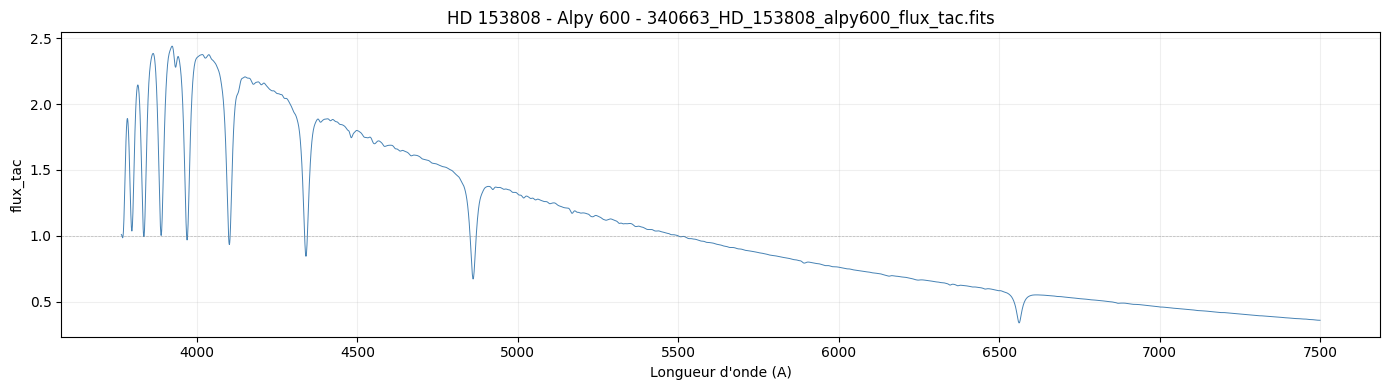

In [17]:
# Verification du FITS 1D
with fits.open(fits_file) as hdul:
    h = hdul[0].header
    d = hdul[0].data
    w_check = h['CRVAL1'] + np.arange(h['NAXIS1']) * h['CDELT1']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(w_check, d, color='steelblue', lw=0.7)
ax.set_xlabel('Longueur d\'onde (A)')
ax.set_ylabel('flux_tac')
ax.set_title(f"{meta['object']} - Alpy 600 - {fits_file}")
ax.axhline(1.0, color='gray', lw=0.5, ls='--', alpha=0.5)
ax.grid(True, which='major', alpha=0.2)
plt.tight_layout()
plt.show()

In [18]:
# Telecharger le fichier
from google.colab import files as colab_files
print(f'Telechargement : {fits_file}')
colab_files.download(fits_file)

Telechargement : 340663_HD_153808_alpy600_flux_tac.fits


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>